In [8]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys
from matplotlib.colors import LinearSegmentedColormap
from numba import njit
#sys.stdout.reconfigure(encoding='utf-8')
matplotlib.rcParams['animation.ffmpeg_path'] = r'C:\Users\Jasper\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1-full_build\bin\ffmpeg.exe'
# -- Parameters ---------------------------------------------------------------
Lx  = 250.0
Ly  = 250.0
Nx  = 250
Ny  = 250
dx  = Lx / Nx
dy  = Ly / Ny

a   = 2.0
m   = 0.45
vtot   = 182.5  # max advection velocity
D   = 1.0        # diffusion coefficient for n
dw = 0.5

T       = 500
dt      = 0.002
n_steps = int(T / dt)

n_eq = (a + np.sqrt((a + 2.*m)*(a - 2.*m))) / (2.*m)
w_eq = a / (1.0 + n_eq**2)

# Stability checks
cfl     = abs(vtot) * dt / dx
diff_nu = D * dt / dx**2
print(f"CFL number (advection): {cfl:.3f}  {'[UNSTABLE]' if cfl > 1 else '[OK]'}")
print(f"Diffusion number:       {diff_nu:.3f}  {'[UNSTABLE]' if diff_nu > 0.5 else '[OK]'}")
print(f"n_eq = {n_eq:.4f},  w_eq = {w_eq:.4f}")

x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)

import numpy as np

def make_terrain_and_velocity(Nx, Ny, Lx, Ly, vtot, n_octaves=8, seed=41):
    """
    Generate periodic rolling-hill terrain and a divergence-free velocity field
    derived from it, with max speed = vtot.

    Returns:
        h  : (Ny, Nx) terrain height field
        vx : (Ny, Nx) x-velocity
        vy : (Ny, Nx) y-velocity
    """
    rng = np.random.default_rng(seed)

    # -- Periodic terrain via Fourier modes -----------------------------------
    # Only use integer wavenumbers so the field tiles exactly on [0,Lx] x [0,Ly]
    h = np.zeros((Ny, Nx))

    for octave in range(n_octaves):
        freq  = 2 ** octave          # 1, 2, 4, 8, 16, 32
        amp   = 1.0 / (freq ** 0.9)  # amplitude falls with frequency (0.9 = gentle rolloff, use 1.0 for rougher)

        # random integer wavenumbers in each direction for this octave
        size = 3
        kx_int = rng.integers(-freq, freq + 1, size=size)
        ky_int = rng.integers(-freq, freq + 1, size=size)
        phases = rng.uniform(0, 2 * np.pi, size=size)

        x = np.linspace(0, Lx, Nx, endpoint=False)
        y = np.linspace(0, Ly, Ny, endpoint=False)
        X, Y = np.meshgrid(x, y)

        for kx_i, ky_i, phi in zip(kx_int, ky_int, phases):
            h += amp * np.sin(2 * np.pi * kx_i * X / Lx
                            + 2 * np.pi * ky_i * Y / Ly
                            + phi)

    # Normalize h to [0, 1]
    h = (h - h.min()) / (h.max() - h.min())

    return h

h = make_terrain_and_velocity(Nx, Ny, Lx, Ly, vtot, seed=42)


CFL number (advection): 0.365  [OK]
Diffusion number:       0.002  [OK]
n_eq = 4.2067,  w_eq = 0.1070


In [9]:
plt.figure(figsize=(6, 5))
plt.imshow(h, origin="lower", extent=[0, Lx, 0, Ly], cmap="terrain")
plt.colorbar(label="height")
plt.title("Generated terrain (h)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig("terrain.png", dpi=200)
plt.close()

print("Saved terrain -> terrain.png")

# -- Initial conditions -------------------------------------------------------
rng = np.random.default_rng(42)

w = w_eq + (rng.random((Ny, Nx)) < 0.02).astype(float)
n = n_eq + (rng.random((Ny, Nx)) < 0.02).astype(float)
#w = a + (rng.random((Ny, Nx)) < 0.02).astype(float)#
#n = 0 + (rng.random((Ny, Nx)) < 0.02).astype(float)

# -- Periodic index arrays ----------------------------------------------------
ixf = np.arange(Nx, dtype=np.int64)
ixb = np.arange(Nx, dtype=np.int64)
iyf = np.arange(Ny, dtype=np.int64)
iyb = np.arange(Ny, dtype=np.int64)

ixf = (ixf + 1) % Nx
ixb = (ixb - 1) % Nx
iyf = (iyf + 1) % Ny
iyb = (iyb - 1) % Ny

# -- Time integration ---------------------------------------------------------
save_every = 500
snapshots_w = []
snapshots_n = []
times       = []

hx, hy = np.gradient(h, dx, dy)

# magnitude of slope
slope = np.sqrt(hx**2 + hy**2)
slope_median = np.median(slope) + 1e-8 
hx, hy = np.gradient(h, dx, dy)

vx_raw = vtot * (hx / slope_median)
vy_raw = vtot * (hy / slope_median)

speed = np.sqrt(vx_raw**2 + vy_raw**2)
scale = np.minimum(1.0, vtot / (speed + 1e-8))

vx = vx_raw * scale
vy = vy_raw * scale

@njit
def step_pde(w, n, vx, vy, dx, dy, dt, a, m, dw, D,
             ixf, ixb, iyf, iyb):

    Ny, Nx = w.shape

    w_new = w.copy()
    n_new = n.copy()

    for j in range(Ny):
        for i in range(Nx):

            # periodic indices
            ip = ixf[i]
            im = ixb[i]
            jp = iyf[j]
            jm = iyb[j]

            # upwind derivatives for w
            if vx[j, i] <= 0:
                dw_dx = (w[j, i] - w[j, im]) / dx
            else:
                dw_dx = (w[j, ip] - w[j, i]) / dx

            if vy[j, i] <= 0:
                dw_dy = (w[j, i] - w[jm, i]) / dy
            else:
                dw_dy = (w[jp, i] - w[j, i]) / dy

            # Laplacian w
            lap_w = (
                (w[j, ip] - 2.0*w[j, i] + w[j, im]) / (dx*dx) +
                (w[jp, i] - 2.0*w[j, i] + w[jm, i]) / (dy*dy)
            )

            # Laplacian n
            lap_n = (
                (n[j, ip] - 2.0*n[j, i] + n[j, im]) / (dx*dx) +
                (n[jp, i] - 2.0*n[j, i] + n[jm, i]) / (dy*dy)
            )

            # PDEs
            w_new[j, i] = w[j, i] + dt * (
                a - w[j, i] - w[j, i]*n[j, i]**2
                + vx[j, i]*dw_dx + vy[j, i]*dw_dy
                + dw * lap_w
            )

            n_new[j, i] = n[j, i] + dt * (
                w[j, i]*n[j, i]**2 - m*n[j, i]
                + D * lap_n
            )

    return w_new, n_new

for step in range(n_steps + 1):
    if step*dt % 10 == 0:
        print(str(step*dt) + "/" +str(T))

    if step % save_every == 0:
        snapshots_w.append(w.copy())
        snapshots_n.append(n.copy())
        times.append(step * dt)

    if step == n_steps:
        break

    w, n = step_pde(
        w, n, vx, vy,
        dx, dy, dt,
        a, m, dw, D,
        ixf, ixb, iyf, iyb
    )

    w = np.clip(w, 0, 1e6)
    n = np.clip(n, 0, 1e6)

print(f"\nSimulation complete. Saved {len(snapshots_w)} snapshots.")


Saved terrain -> terrain.png
0.0/500
10.0/500
20.0/500
30.0/500
40.0/500
50.0/500
60.0/500
70.0/500
80.0/500
90.0/500
100.0/500
110.0/500
120.0/500
130.0/500
140.0/500
150.0/500
160.0/500
170.0/500
180.0/500
190.0/500
200.0/500
210.0/500
220.0/500
230.0/500
240.0/500
250.0/500
260.0/500
270.0/500
280.0/500
290.0/500
300.0/500
310.0/500
320.0/500
330.0/500
340.0/500
350.0/500
360.0/500
370.0/500
380.0/500
390.0/500
400.0/500
410.0/500
420.0/500
430.0/500
440.0/500
450.0/500
460.0/500
470.0/500
480.0/500
490.0/500
500.0/500

Simulation complete. Saved 501 snapshots.


Saved snapshots -> snapshots_2d.png


KeyboardInterrupt: 

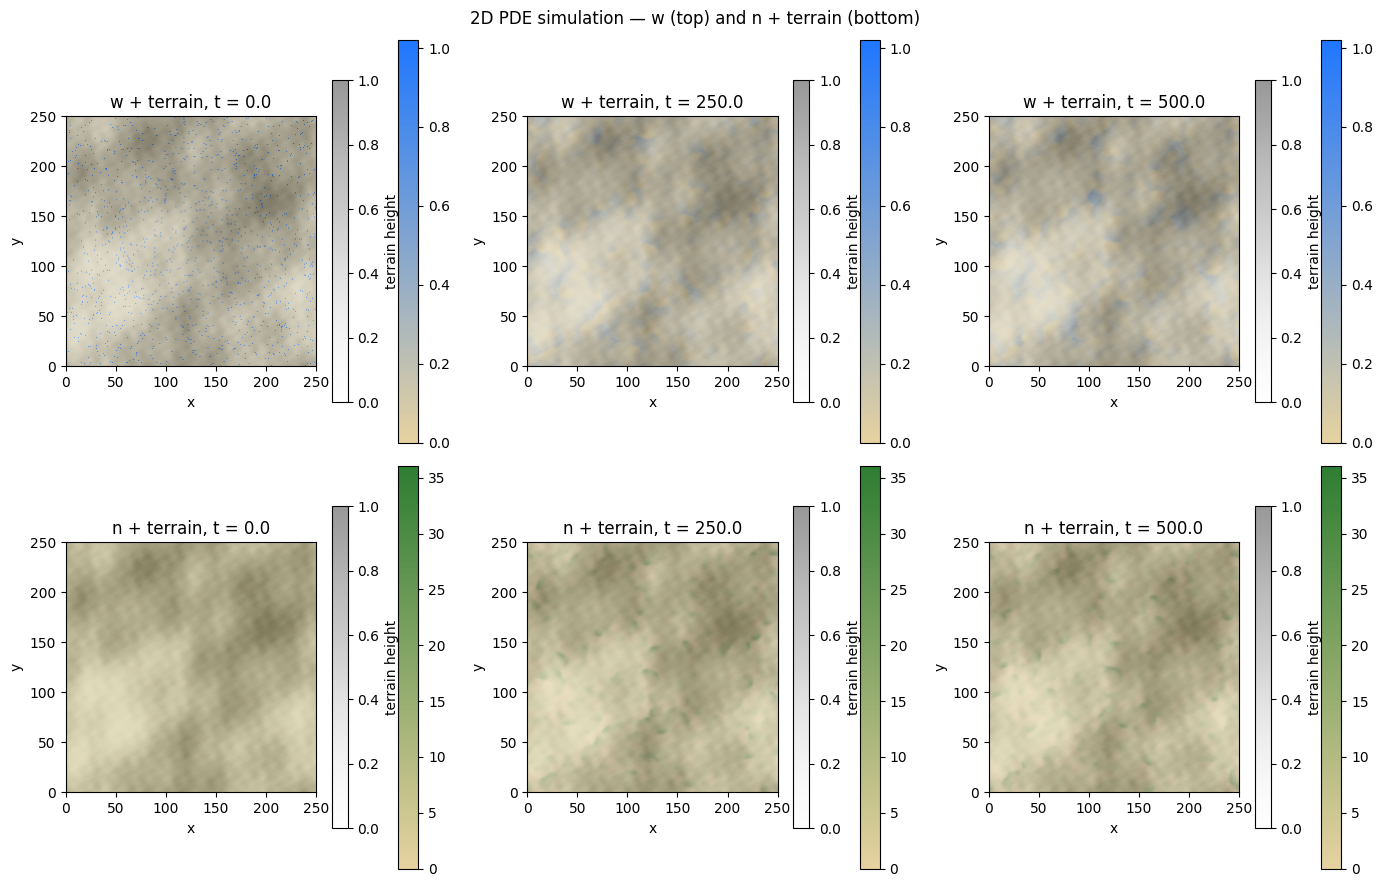

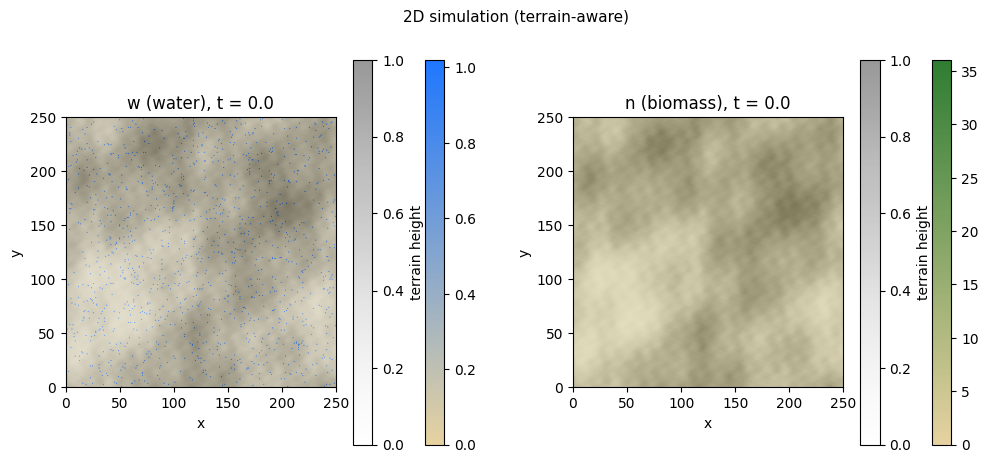

In [ ]:

sand_to_grass = LinearSegmentedColormap.from_list(
    "sand_to_grass",
    ["#e6d2a0", "#2e7d32"]
)
plt.colormaps.register(sand_to_grass, force=True)

sand_to_blue = LinearSegmentedColormap.from_list(
    "sand_to_blue",
    ["#e6d2a0", "#1f77ff"]
)
plt.colormaps.register(sand_to_blue, force=True)


snapshots_w = np.array(snapshots_w)
snapshots_n = np.array(snapshots_n)
times       = np.array(times)

w_min, w_max = snapshots_w[15:].min(), snapshots_w[15:].max()
n_min, n_max = snapshots_n.min(), snapshots_n.max()
n_min = 0
w_min = 0

# normalize terrain once
h_norm = (h - h.min()) / (h.max() - h.min())

# -------------------------------------------------------------------------
# STATIC PLOTS
# -------------------------------------------------------------------------
frames_to_plot = [0, len(times)//2, -1]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("2D PDE simulation — w (top) and n + terrain (bottom)", fontsize=12)
alpha = 0.4
for col, fi in enumerate(frames_to_plot):

    # --- w ---
    im0 = axes[0, col].imshow(
        snapshots_w[fi],
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="sand_to_blue",
        vmin=w_min,
        vmax=w_max
    )
    
    im0_h_static = axes[0, col].imshow(
        h_norm,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="Greys",
        alpha=alpha
    )
    axes[0, col].set_title(f"w + terrain, t = {times[fi]:.1f}")
    axes[0, col].set_xlabel("x")
    axes[0, col].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0, col])
    plt.colorbar(im0_h_static, ax=axes[0, col], shrink=0.8, label="terrain height")

    # --- n (base) ---
    im1 = axes[1, col].imshow(
        snapshots_n[fi],
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="sand_to_grass",
        vmin=n_min,
        vmax=n_max
    )

    # --- terrain overlay (IMPORTANT: store handle) ---
    im1_h_static = axes[1, col].imshow(
        h_norm,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="Greys",
        alpha=alpha
    )

    axes[1, col].set_title(f"n + terrain, t = {times[fi]:.1f}")
    axes[1, col].set_xlabel("x")
    axes[1, col].set_ylabel("y")

    plt.colorbar(im1, ax=axes[1, col])
    plt.colorbar(im1_h_static, ax=axes[1, col], shrink=0.8, label="terrain height")

plt.tight_layout()
plt.savefig("snapshots_2d.png", dpi=150)
print("Saved snapshots -> snapshots_2d.png")


# -------------------------------------------------------------------------
# ANIMATION
# -------------------------------------------------------------------------
fig2, (ax_w, ax_n) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("2D simulation (terrain-aware)", fontsize=11)

im_w = ax_w.imshow(
    snapshots_w[0],
    origin="lower",
    extent=[0, Lx, 0, Ly],
    cmap="sand_to_blue",
    vmin=w_min,
    vmax=w_max,
    animated=True
)

# terrain overlay (static)
imw_h = ax_w.imshow(
    h_norm,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    cmap="Greys",
    alpha=alpha,
    animated=True
)


ax_w.set_title("w (activator)")
ax_w.set_xlabel("x")
ax_w.set_ylabel("y")
plt.colorbar(im_w, ax=ax_w)
plt.colorbar(imw_h, ax=ax_w, label="terrain height")

im_n = ax_n.imshow(
    snapshots_n[0],
    origin="lower",
    extent=[0, Lx, 0, Ly],
    cmap="sand_to_grass",
    vmin=n_min,
    vmax=n_max,
    animated=True
)

# terrain overlay (static)
imn_h = ax_n.imshow(
    h_norm,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    cmap="Greys",
    alpha=alpha,
    animated=True
)

ax_n.set_title("n (biomass) + terrain")
ax_n.set_xlabel("x")
ax_n.set_ylabel("y")

plt.colorbar(im_n, ax=ax_n)
plt.colorbar(imn_h, ax=ax_n, label="terrain height")


title_w = ax_w.set_title("w, t = 0")
title_n = ax_n.set_title("n, t = 0")


def update(frame):
    im_w.set_data(snapshots_w[frame])
    im_n.set_data(snapshots_n[frame])

    title_w.set_text(f"w (water), t = {times[frame]:.1f}")
    title_n.set_text(f"n (biomass), t = {times[frame]:.1f}")

    return im_w, im_n, imw_h, imn_h, title_w, title_n


ani = animation.FuncAnimation(
    fig2,
    update,
    frames=len(times),
    interval=60,
    blit=False
)

ani.save("animation_2d.gif", writer="pillow", fps=20)
ani.save("animation_2d.mp4", writer="ffmpeg", fps=20, dpi=300,)
print("Saved animation -> animation_2d.gif")

plt.show()

C:\Users\Jasper\AppData\Local\Temp\ipykernel_14176\2213749948.py:5: UserWarning: Overwriting the cmap 'sand_to_grass' that was already in the registry.
  plt.colormaps.register(sand_to_grass, force=True)
C:\Users\Jasper\AppData\Local\Temp\ipykernel_14176\2213749948.py:11: UserWarning: Overwriting the cmap 'sand_to_blue' that was already in the registry.
  plt.colormaps.register(sand_to_blue, force=True)


Saved snapshots -> snapshots_2d.png
Saved animation -> animation_n_only.gif


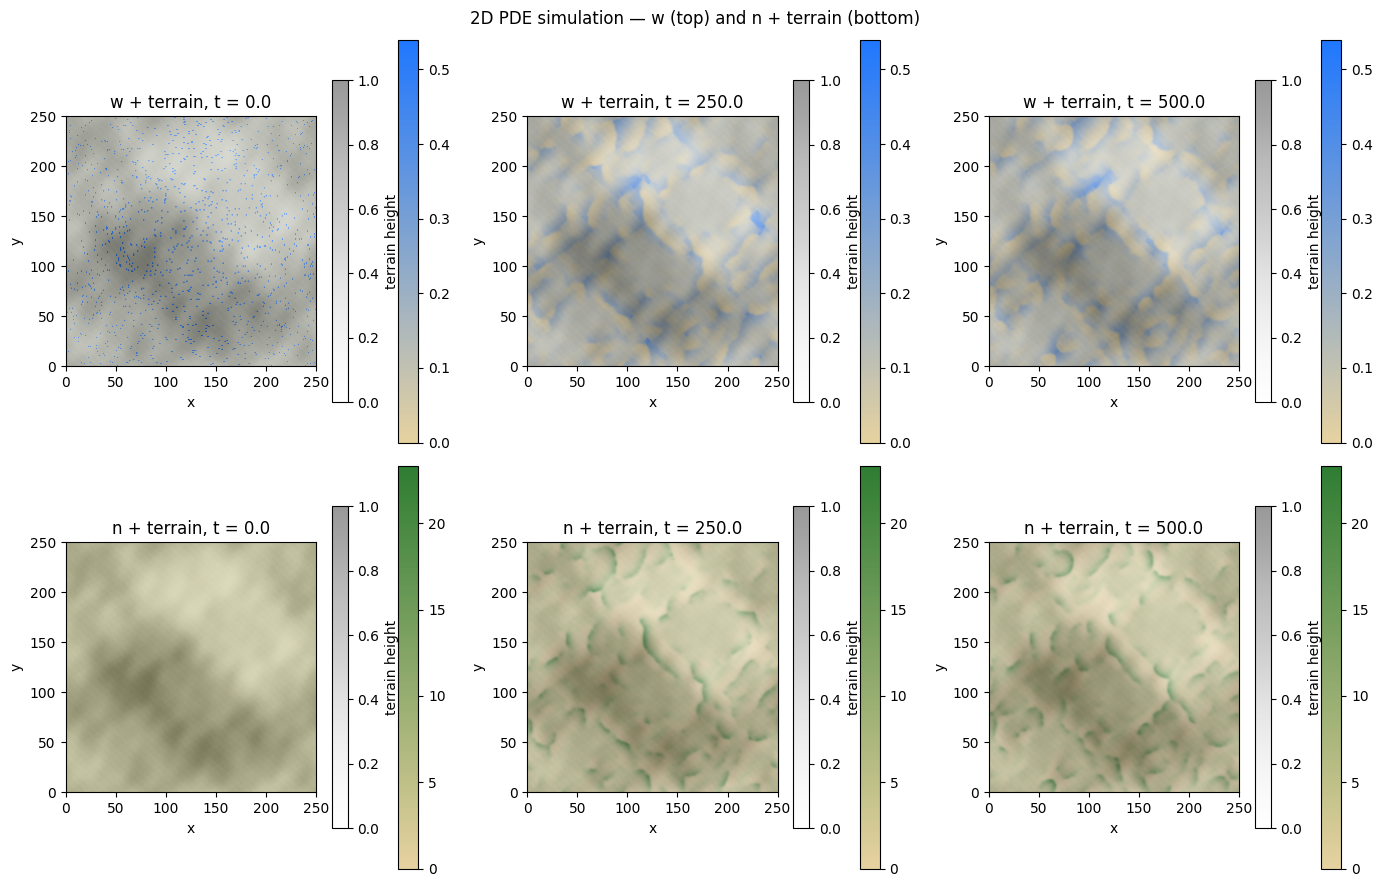

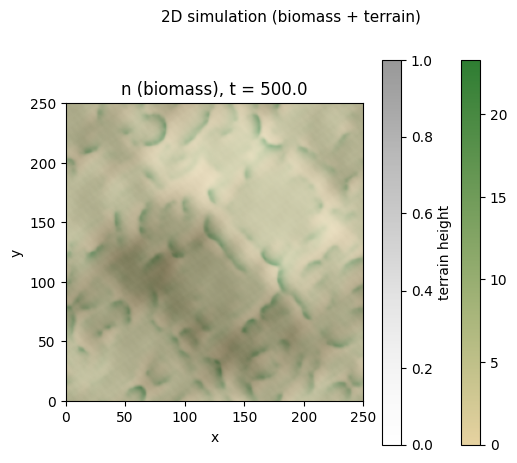

In [10]:

sand_to_grass = LinearSegmentedColormap.from_list(
    "sand_to_grass",
    ["#e6d2a0", "#2e7d32"]
)
plt.colormaps.register(sand_to_grass, force=True)

sand_to_blue = LinearSegmentedColormap.from_list(
    "sand_to_blue",
    ["#e6d2a0", "#1f77ff"]
)
plt.colormaps.register(sand_to_blue, force=True)


snapshots_w = np.array(snapshots_w)
snapshots_n = np.array(snapshots_n)
times       = np.array(times)

w_min, w_max = snapshots_w[15:].min(), snapshots_w[15:].max()
n_min, n_max = snapshots_n.min(), snapshots_n.max()
n_min = 0
w_min = 0

# normalize terrain once
h_norm = (h - h.min()) / (h.max() - h.min())

# -------------------------------------------------------------------------
# STATIC PLOTS
# -------------------------------------------------------------------------
frames_to_plot = [0, len(times)//2, -1]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("2D PDE simulation — w (top) and n + terrain (bottom)", fontsize=12)
alpha = 0.4
for col, fi in enumerate(frames_to_plot):

    # --- w ---
    im0 = axes[0, col].imshow(
        snapshots_w[fi],
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="sand_to_blue",
        vmin=w_min,
        vmax=w_max
    )
    
    im0_h_static = axes[0, col].imshow(
        h_norm,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="Greys",
        alpha=alpha
    )
    axes[0, col].set_title(f"w + terrain, t = {times[fi]:.1f}")
    axes[0, col].set_xlabel("x")
    axes[0, col].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0, col])
    plt.colorbar(im0_h_static, ax=axes[0, col], shrink=0.8, label="terrain height")

    # --- n (base) ---
    im1 = axes[1, col].imshow(
        snapshots_n[fi],
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="sand_to_grass",
        vmin=n_min,
        vmax=n_max
    )

    # --- terrain overlay (IMPORTANT: store handle) ---
    im1_h_static = axes[1, col].imshow(
        h_norm,
        origin="lower",
        extent=[0, Lx, 0, Ly],
        cmap="Greys",
        alpha=alpha
    )

    axes[1, col].set_title(f"n + terrain, t = {times[fi]:.1f}")
    axes[1, col].set_xlabel("x")
    axes[1, col].set_ylabel("y")

    plt.colorbar(im1, ax=axes[1, col])
    plt.colorbar(im1_h_static, ax=axes[1, col], shrink=0.8, label="terrain height")

plt.tight_layout()
plt.savefig("snapshots_2d.png", dpi=150)
print("Saved snapshots -> snapshots_2d.png")


# -------------------------------------------------------------------------
# ANIMATION (ONLY n)
# -------------------------------------------------------------------------
fig2, ax_n = plt.subplots(figsize=(6, 5))
fig2.suptitle("2D simulation (biomass + terrain)", fontsize=11)

# --- n field ---
im_n = ax_n.imshow(
    snapshots_n[0],
    origin="lower",
    extent=[0, Lx, 0, Ly],
    cmap="sand_to_grass",
    vmin=n_min,
    vmax=n_max,
    animated=True
)

# --- terrain overlay ---
imn_h = ax_n.imshow(
    h_norm,
    origin="lower",
    extent=[0, Lx, 0, Ly],
    cmap="Greys",
    alpha=alpha,
    animated=True
)

ax_n.set_xlabel("x")
ax_n.set_ylabel("y")

# colorbars
plt.colorbar(im_n, ax=ax_n)
plt.colorbar(imn_h, ax=ax_n, label="terrain height")

# title
title_n = ax_n.set_title("n (biomass), t = 0")

# --- update function ---
def update(frame):
    im_n.set_data(snapshots_n[frame])
    title_n.set_text(f"n (biomass), t = {times[frame]:.1f}")
    return im_n, imn_h, title_n

# --- animation ---
ani = animation.FuncAnimation(
    fig2,
    update,
    frames=len(times),
    interval=60,
    blit=False
)

# --- save ---
ani.save("animation_n_only.gif", writer="pillow", fps=20)
ani.save("animation_n_only.mp4", writer="ffmpeg", fps=20, dpi=300)

print("Saved animation -> animation_n_only.gif")

plt.show()